In [1]:
#Loads scripts, libraries, etc.
print('Hello, lets get started')
%matplotlib widget
import importlib
import PyMca5
import os
from analyze_sgm_bsky_data import analyze_sgm_bsky_data
from alignment_utils import interactive_roll_align
from stitching_utils import stitch_quadrant_maps
from alignment_utils import visualize_stitching_overlap
from stitching_utils import interactive_stitching_trim
from sum_mcc1_spectra import sum_mcc1_spectra
from save_pymca_stack_h5 import save_pymca_stack_h5
from calibrate_sdd_xrf import run_calibration
import sdd_calibration_utils as calib_utils
from calibrate_sdd_xrf import SDDCalibrationGUI
from plot_sgm_bsky_data import plot_sgm_bsky_data
from pca_xanes_analysis import pca_xanes_analysis
from interactive_cluster_merger import interactive_cluster_merger
from pca_xanes_analysis import run_pca_all_detectors
from cluster_xanes_analysis import run_clustering_all_detectors
from save_pymca_4d_stack_h5 import save_pymca_4d_stack_h5
from pca_stack_analysis import pca_stack_analysis
from cluster_pca_spectra import cluster_pca_spectra
from pca_xanes_analysis import pca_xanes_analysis
from cluster_xanes_analysis import cluster_xanes_analysis
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
os.environ["OMP_NUM_THREADS"] = "2"

print('Done loading libraries')

Hello, lets get started

[VERSION] Dashboard Engine v2.5 (ROI FIXED)

Done loading libraries


Please select 4 HDF5 quadrant files...
  -> Selected SW (South-West): Trial1-Tan4T-SW_map_2026-05-07_095323_0.00eV.h5
  -> Selected SE (South-East): Trial1-Tan4T-SE_map_2026-05-07_100854_0.00eV.h5
  -> Selected NE (North-East): Trial1-Tan4T-NE_map_2026-05-07_102424_0.00eV.h5
  -> Selected NW (North-West): Trial1-Tan4T-NW_map_2026-05-07_103955_0.00eV.h5


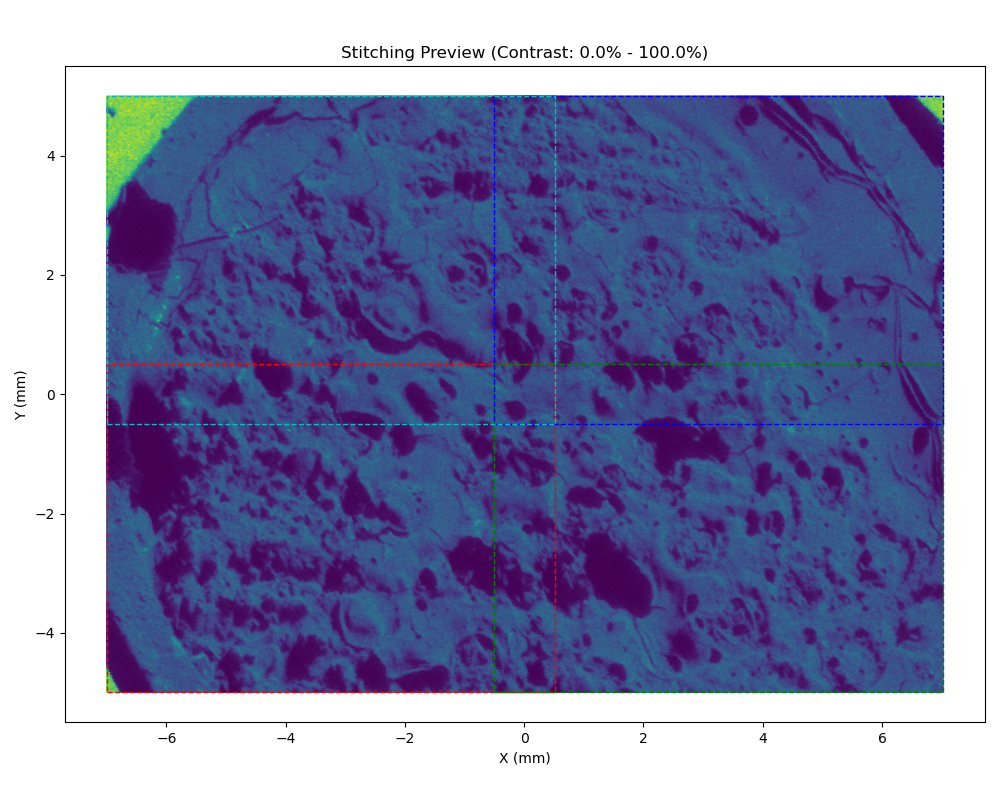

In [2]:
# This will stitch 4 images together.
stitched_h5=interactive_stitching_trim()

In [3]:
# Browse to the stitched image to load
sgm_data = analyze_sgm_bsky_data()



Analyzing File: D:\Data\Testing_jupyter-python-axis2000\4-quadrant_maps\stitched\Stitched_Trial1-Tan4T-SW_map.h5

--- Scan Analysis Summary ---
Energies (1 points): [0.]
Number of Images:      1
Energy Regions:        0.00: 0.0 eV
X array (shape):       (363608,) (Nx: 562)
Y array (shape):       (363608,) (Ny: 602)
Grid Dimensions:       562 x 602
----------------------------
Date:                  1778169203.2995694
Scan Name:             Trial1-Tan4T-SW_map
Project:               39M14239
Beamline:              sgm_ambxas
Polarization:          N/A
Grating:               N/A
Harmonic:              N/A
Strip:                 N/A
Command:               N/A
Coordinates:           X: -7.00 to 7.03, Y: -5.00 to 5.00
Exit Slit Gap:         25.035131136
XPS Z:                 -1.5060000000000002
Time Per Map:          N/A
Number of Points:      N/A

MCC Files Found:       1

SDD Files Found:
  Detector sdd1: 1 files
  Detector sdd2: 1 files
  Detector sdd3: 1 files
  Detector sdd4: 1 files

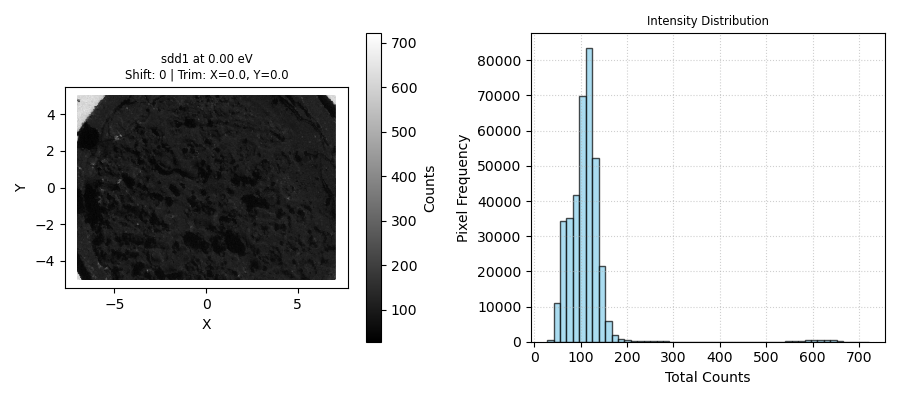

In [4]:
# Allows for the alignment of the stack to be checked
# Allows for removing some pixels ( as mm units) on the X and Y edges, which makes the stack dimensions smaller
# The new dimensions will be used in the plotting and PCA/CA
# This step can be skipped
interactive_roll_align(sgm_data, (20,40), use_color=False)

In [5]:
# Maps the fluorescence and sample TEY signal.  Can select which image for the map.
# Plots the fluorescence and TEY spectra from a stack- saves Raw and Normalized XANES spectra for each SDD, I0 and sample TEY as a csv file.
# Saves XRF spectra for each SDD as a csv file. Saves images (i.e., maps) for each SDD.
# Can change the ROI from the XRF spectrum to select the edge of interest. Each bin  about 10 eV.
# Can change the area selected on the image by dragging a rectangle or making a polygon over the area of interest. Can toggle between the two. 
# Note that the area selected will be where the spectra are derived from and saves in the csv file.
# To see the changes in the spectra need to click on the "Refresh Plots" button.
# Can use the internal I0 from the Au mesh (mcc1) or load an external I0 from a csv file for normalization- allows for which column to select
# MCC1 is the I0 from Au mesh before the KB mirrors, MCC2 is from a photodiode behind the sample (only recorded when no sample in the pathway), 
# which could be used as and Io, , MCC3 auxillary, MCC4 is TEY signal from the sample. 
# Can either show lines with or withput individual data points
# Can zoom in on spectra using tools on left.   
# Mouse over an image or plot and get the X and Y coordinates.
# Automatically adjusts the contrast for each image.  
# Plot as a scatter map (usual way) or as a heatmap.
# The default ROI on the XRF spectra is 0-255.  Drag left and right edges on the XRF spectra to select the ROI for the element of interest.
# Each bin is about 10 eV. 
# Calibrate the energy by adding an energy shift value - energy_shift = 0 as default.
# To add detailed information to the header change use_full_metadata = True.
# Can display spectra with the data points or not- show_markers = False spectra plotted without data points shown
# Can change the display of the images, selecting grey scale or color

plot_sgm_bsky_data(sgm_data, as_scatter_plot=True, fixed_roi=False, mcc_to_map=[4], channel_roi =[20,40], show_markers=False, mcc_channels = [1,4], energy_shift=0)
#plot_sgm_bsky_data(sgm_data, as_scatter_plot=True, use_color=False, fixed_roi=False, channel_roi =[30,50])

  [Auto Select] Defaulting to middle energy: 0.00 eV
--- SDD Stack Dashboard: Trial1-Tan4T-SW_map ---
  [Metadata] Full Headers: Disabled
  Location: D:\Data\Testing_jupyter-python-axis2000\4-quadrant_maps\stitched
  [Alignment] Roll Shift: 0 | Trim: X=0.000 mm, Y=0.000 mm
  Pass 1: Pre-loading energy dependence...


In [ ]:
# For calibrating XRF spectra for each SDD
# Saves a Json file that can be applied to all XRD spectra in plotting
# Should only need to be done when conditions change on the beamline but could be done for each experiment
run_calibration()